# Monte Carlo Sampling

The `MonteCarlo` class generates synthetic debris disc particle positions via orbital sampling from an input surface density profile $\Sigma_a(a)$ and an eccentricity distribution $\psi(e, a)$. It supports both unique eccentricity profiles and general distributions. 

This is particularly useful for validating the ASD results obtained through the main semi-analytic pipeline. 

## Sampling the 1D $\bar\Sigma(r)$ Profile

The Monte Carlo approach enables the estimation of the azimuthally symmetric surface density profile, $\bar\Sigma(r)$, by generating and binning random samples of orbital positions. This method is especially useful for validating analytical results or for exploring eccentricity distributions that are difficult or inefficient to integrate directly.

To begin, the `MonteCarlo` object is initialised by passing in the pre-defined `SigmaA` and `Eccentricity` objects. These are the same as those used in the main analytical pipeline, ensuring a cohesive and consistent modelling framework.

Once initialised, samples can be generated by calling the `sampler()` method. Internally, this first samples particle semi-major axes, $a$, from the distribution $\Sigma_a(a)$, using rejection sampling. When computing a 1D radial profile, the user must sample from the distribution $a_i \sim \Sigma_a(a) \cdot a$, where the additional factor of $a$ arises from the coordinate transformation Jacobian. This correction is essential to enforce mass conservation. The user can control this behaviour with the `use_jacobian=True` flag (enabled by default).

The method then proceeds to draw eccentricities and solve Kepler’s equation to obtain the corresponding radial distances, $r$. We refer the reader to the API documentation for full details of this internal calculation.

Setting `verbose=True` provides real-time feedback on the sampling progress. Additionally, by enabling `return_samples=True`, the function returns the following arrays:

- `a_samples`: Semi-major axis values drawn from $\Sigma_a(a)$.
- `r_samples`: Radial positions calculated from each $(a, e, f)$ sample.
- `e_samples`: Eccentricities sampled from the specified eccentricity profile.
- `f_samples`: True anomalies corresponding to each orbit.

These arrays can be used to visualise or analyse the distribution of sampled orbits, and to construct histograms approximating $\bar\Sigma(r)$.

### Unique Eccentricity Profile

In the unique eccentricity case, $e=e(a)$, so the eccentricity for each particle is trivially computed once the semi-major axis positions have been sampled.

In [1]:
from debrispy import SigmaA, UniqueEccentricity, MonteCarlo

# Initialise the surface density profile and eccentricity profile
sigma_a = SigmaA(a_min = 1, a_max = 4, sigma0 = 1, power = 0.5)
ecc_profile = UniqueEccentricity(a_min = 1, a_max = 4, e0 = 0.5, power = 0.7)

# Initialise the Monte Carlo Sampler
mc = MonteCarlo(sigma_a, ecc_profile, n_samples = 1_000_000)

# Sample the 1D profile
a_samples, r_samples, e_samples, f_samples = mc.sampler(use_jacobian = True, verbose = True, return_samples = True)

Sampling semi-major axis...
Sampling eccentricities...
Solving Kepler's equation...
Done.


#### Histogram1D Objects

After sampling, the estimated surface density profiles must be normalised by the corresponding bin widths before plotting. This converts raw histogram counts into a proper density estimate rather than a count distribution. In this library, this normalisation is handled automatically by the `get_1d_histogram` method.

This method returns two `Histogram1D` objects representing the semi-major axis distribution $\Sigma_a(a)$ and the azimuthally averaged radial distribution $\bar{\Sigma}(r)$. Internally, it constructs the histograms, computes the bin widths, and applies the required normalisation to obtain density estimates.

By default, the optional argument `scale=True` ensures that the total mass represented by the histograms is consistent with the underlying physical model. Specifically, the histograms are rescaled so that their integrals match the integral of the analytical $\Sigma_a(a)$ profile, preserving the total mass.


In [2]:
histogram_a, histogram_r = mc.get_1d_histogram(bins = 500, scale = True) # Returns two Histogram1D objects

`Histogram1D` objects are lightweight containers that store the bin edges, bin centres, bin widths, and the corresponding histogram values. These objects are created internally by the library and returned to the user as a convenient interface for working with one-dimensional histograms. Examples of typical usage are provided below.

In [3]:
# Get bin centers
bin_centers = histogram_a.centers

# Get bin widths
bin_widths = histogram_a.widths

# Get bin edges, centers and centre values
hist_a_edges, hist_a_centers, hist_a_values = histogram_a.get_values()

#### Plotting the Histograms

The resulting histograms for semi-major axis and radius can be directly visualised **together** using the `plot_1d` method directly within the `MonteCarlo` class. 

This will plot both the semi-major axis profile $\Sigma_a(a)$ and the sampled radial profile $\bar\Sigma(r)$, using 500 bins by default. Several keyword options allow for further customisation:

- `bins` (`int`): Number of bins used in both histograms. Default is `500`.

- `save` (`bool`): If `True`, saves the plot to disk. Requires `filepath` to be specified.

- `filepath` (`str`): Path to save the figure if `save=True`.

- `overlay` (`bool`): If `True`, overlays the sampled profile with the analytic result from the `ASD` class for comparison (requies the user to supply the precomputed ASD).

- `scale` (`bool`): If `True`, normalises histograms to match the area under the analytic $\Sigma_a(a)$ curve.

- `asd` (`ASD` object): Optional. If provided and `overlay=True`, this analytic profile is plotted alongside the Monte Carlo results.

- `x_lim`, `y_lim` (`tuple`): Optional axis limits for more controlled visual output.

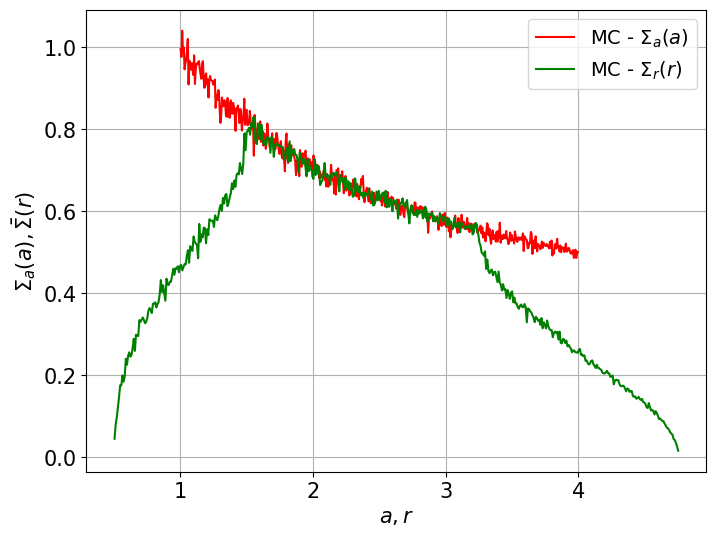

In [4]:
# If bins not specified, will use the default

mc.plot_1d(bins = 500, scale = True, overlay = False)

In order to overlay the ASD, the user needs to compute it separately.

In [5]:
import numpy as np
from debrispy import Kernel, ASD

kernel = Kernel(ecc_profile, r_min = 0.01, r_max = 5)
kernel.compute()

asd = ASD(kernel, sigma_a)
asd.compute_gl(r_vals = np.linspace(0.01, 5, 500), n_points = 128, n_jobs = -1, show_progress = False)

Computing ASD with Gauss-Legendre (with fixed limits)...
Done. Final result has 500 valid points.



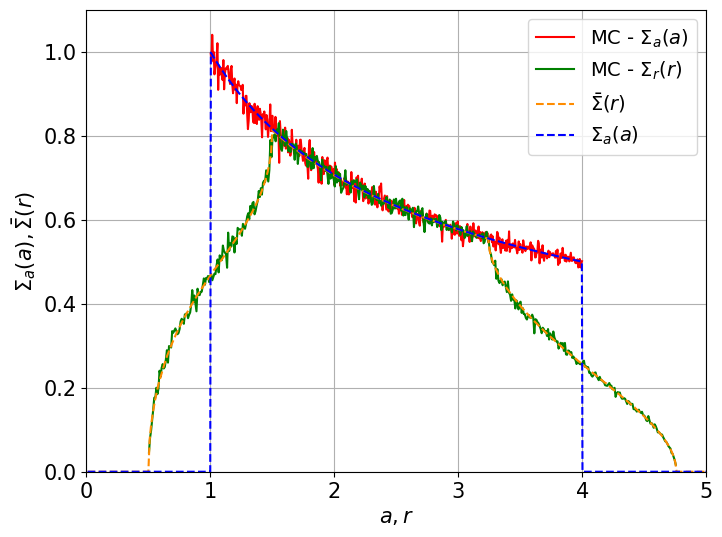

In [6]:
mc.plot_1d(overlay = True, asd = asd, x_lim=(0, 5), y_lim=(0, 1.1))

### Eccentricity Distribution

The method and user interface remain identical when the provided eccentricity profile is a distribution, $\psi(e, a)$. The only difference lies in how eccentricities are sampled. 

In the unique eccentricity case, the eccentricity for each particle is deterministically computed from a fixed function. However, when using a distribution, the eccentricity **must be sampled individually** for each particle based on its semi-major axis. That is, for each sampled value $a_i$, the corresponding eccentricity is drawn from a conditional distribution:

$$
e_i \sim \psi(e \mid a_i)
$$

This makes the sampling process inherently more computationally expensive than the unique case, as it requires evaluating the distribution and performing rejection sampling for each individual particle.


In [7]:
from debrispy import SigmaA, RayleighEccentricity, MonteCarlo

disc = SigmaA(a_min=1, a_max=4, sigma_0=1, power=0.5, profile_type="power_law")
ecc_rayleigh = RayleighEccentricity(1, 4, sigma0=0.4, power=0.5)

mc = MonteCarlo(disc, ecc_rayleigh, n_samples=1_000_000)
a_samples, r_samples, e_samples, f_samples = mc.sampler(use_jacobian = True)

Sampling semi-major axis...
Sampling eccentricities...
Solving Kepler's equation...
Done.


In [8]:
kernel = Kernel(ecc_rayleigh, r_min = 0.01, r_max = 6)
kernel.compute()

asd = ASD(kernel, disc)
asd.compute_gl(r_vals = np.linspace(0.01, 6, 500), n_points = 64, n_jobs = -1, show_progress = False)

Computing ASD with Gauss-Legendre (with fixed limits)...
Done. Final result has 500 valid points.



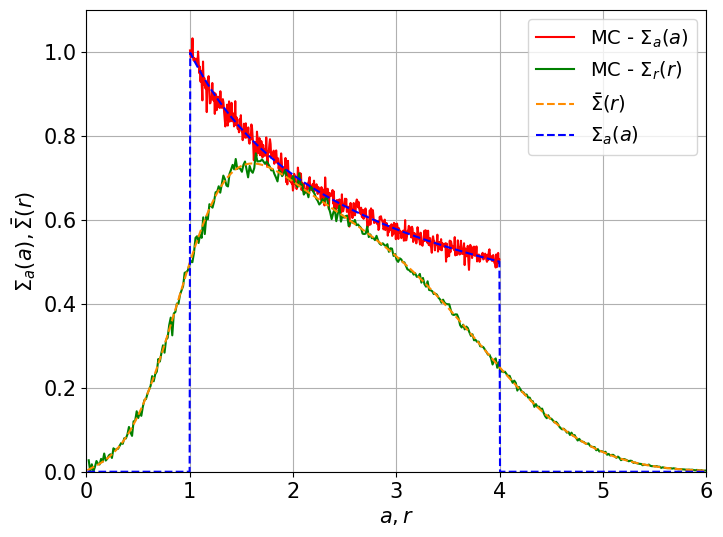

In [9]:
mc.plot_1d(overlay = True, scale = True, asd = asd, x_lim=(0, 6), y_lim=(0, 1.1))

## Sampling the Full $\Sigma(r, \phi)$ Distribution

In addition to the 1D surface density profile, the Monte Carlo sampler can be used to reconstruct the full 2D spatial distribution $\Sigma(r, \phi)$. 

To generate this 2D distribution, the user can use the same `sampler` method as before. However, for the 2D case, *the Jacobian factor must be omitted*, `use_jacobian = False`.

This is because $\Sigma(r, \phi)$ represents particle counts in physical space rather than mass conservation in annular shells, therefore the Jacobian weighting for mass conservation (used in 1D) is not required here.

In [10]:
disc = SigmaA(1, 6, profile_type = 'power_law', power = 0.5)
ecc = UniqueEccentricity(1, 6, e0=0.5, power=0.7)
mc = MonteCarlo(disc, ecc, n_samples=50_000_000)

mc.sampler(use_jacobian = False, verbose = True, return_samples = False)

Sampling semi-major axis...
Sampling eccentricities...
Solving Kepler's equation...
Done.


To convert the sampled $r$ values obtained from the sampler into a two-dimensional spatial distribution, the user must provide the functional form of the apsidal angle, $\varpi(a)$.

The library provides two functions for constructing two-dimensional histograms: `get_polar_histogram`, which generates a histogram in $(r, \phi)$ coordinates, and `get_cart_histogram`, which generates a histogram in $(x, y)$ coordinates.

Both functions construct and return `Histogram2D` objects. Similar to `Histogram1D`, these objects act as convenient containers for storage, in this case for the bin edges and values.

The bins argument controls the resolution along each axis. For example, bins=500 produces a $500 \times 500$ histogram in both the polar and Cartesian cases.


In [11]:
def varpi_func(a):
    return a**(1.2)

polar_histogram = mc.get_polar_histogram(bins = 500, varpi_func=varpi_func)         # Returns a Histogram2D object
cartesian_histogram = mc.get_cart_histogram(bins = 500, varpi_func=varpi_func)      # Returns a Histogram2D object

# Get the bin edges and values
x_edges, y_edges, values = cartesian_histogram.get_values()

These histograms can be automatically visualised using the `plot_2d` method. The user can control the output through several keyword arguments:

- `varpi_func` (callable, optional): Function that maps semi-major axis `a` to apsidal angle $\varpi(a)$.

- `bins` (int): Number of bins in the histogram (effectively n x n).

- `log` (bool): If `True`, applies logarithmic colour scaling for better contrast in regions of low particle density.

- `mode` (str): Choose between `'cartesian'` and `'polar'` views.  

  - `'cartesian'` plots the 2D density in $x$–$y$ space.  
  - `'polar'` plots in $r$–$\phi$ space.

- `save` (bool): If `True`, saves the resulting figure. Requires `filepath` to be specified.

- `filepath` (str or Path, optional): File path to save the figure if `save=True`.

Generating 2D histogram in cartesian coordinates...


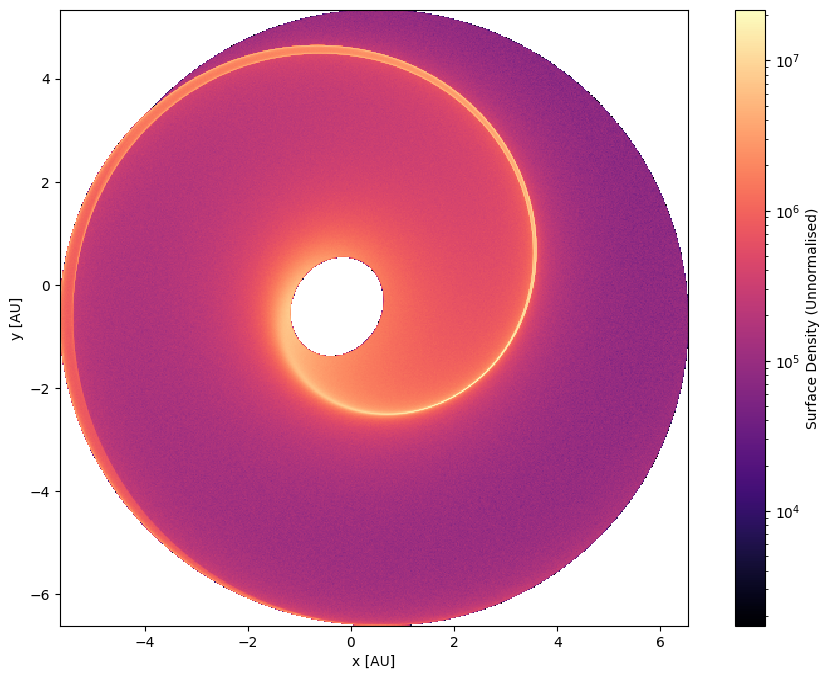

In [12]:
mc.plot_2d(varpi_func=varpi_func, bins=500, mode='cartesian', save=False)

Generating 2D histogram in polar coordinates...


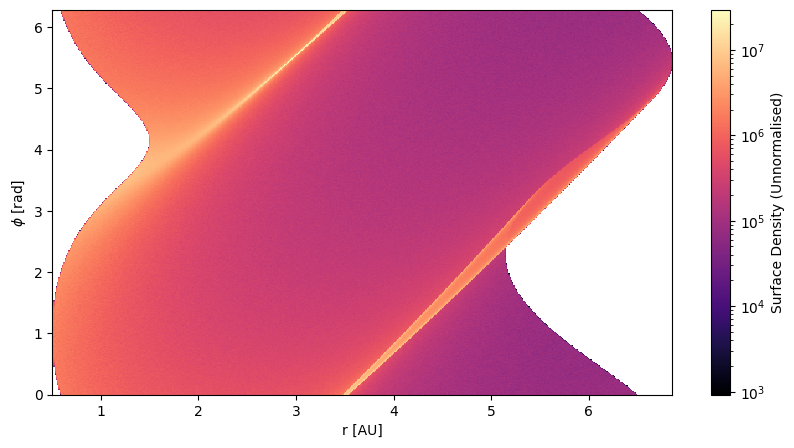

In [13]:
mc.plot_2d(varpi_func=varpi_func, bins=500, mode='polar', save=False)

## Additional Properties of 2D Histograms

`Histogram2D` objects provide additional utilities for manipulating two-dimensional histograms after they have been constructed. In particular, they support padding to specified spatial limits and Gaussian convolution to mimic observational resolution effects.

### Padding Histograms

The `pad_to_limits` method allows a histogram to be extended or cropped to specified spatial limits. When extending the histogram, new bins are added outside the original domain using the same mean bin spacing as the existing grid. These new bins are filled with a constant value specified by floor_value (default is 0.0).

If the requested limits lie within the original histogram extent, the histogram is instead cropped to the requested region.

This method is useful when multiple histograms need to be aligned on the same spatial grid or when enforcing consistent plotting limits.

In [14]:
# This returns a NEW Histogram2D object whose spatial extent covers the requested limits.
H_padded = cartesian_histogram.pad_to_limits(xlim=(-10, 10), ylim=(-10, 10), floor_value=0.0)

### Gaussian Convolution

The `convolve_gaussia` method convolves the histogram with a rotated two-dimensional Gaussian kernel. This can be used to mimic instrumental resolution or observational point-spread functions (PSFs).

The Gaussian width can be specified either in terms of FWHM (via `fwhm_x` and `fwhm_y`) or standard deviation (via `sigma_x` and `sigma_y`) in the physical units of the histogram axes. If only one axis is provided, the Gaussian is assumed to be circular.

The kernel can also be rotated by an angle theta (via the argument `theta` which is in radians), allowing anisotropic or inclined PSFs to be represented.

Internally, the convolution is performed using FFT-based convolution for efficiency. Additional padding is automatically applied during the convolution to ensure that the Gaussian "wings" are properly captured.

In [15]:
convolved = cartesian_histogram.convolve_gaussian(sigma_x=0.1, sigma_y=0.2, theta= 3)
x_edges, y_edges, values = convolved.get_values()

When plotting a convolved histogram using the `plot()` method, the shape and orientation of the Gaussian PSF can be displayed as a small ellipse in the lower-left corner of the figure by setting `show_psf=True`. This visual marker represents the effective beam (using the FWHM of the Gaussian) and provides a convenient reference for the spatial resolution of the convolved map.

The colour, location and opacity of this marker can be altered as shown below.

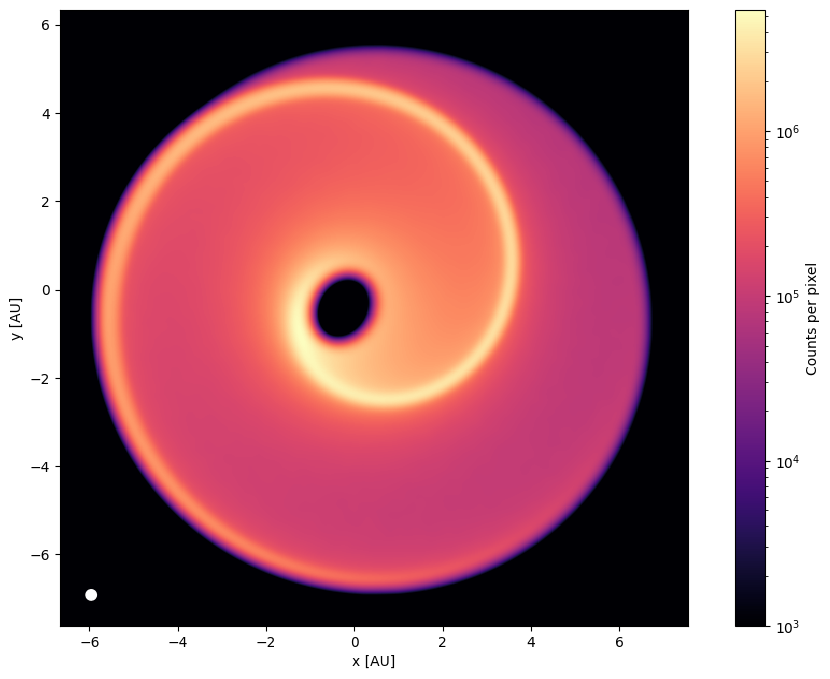

In [16]:
convolved = cartesian_histogram.convolve_gaussian(sigma_x=0.1, sigma_y=0.1, theta= 3, pad = 10)
ax = convolved.plot(cmap = "magma", log = True, floor_threshold=1e3, floor_value=1e3, 
                    show_psf=True, psf_scale=1, psf_loc=(0.05, 0.05), 
                    psf_facecolor="white", psf_edgecolor="white", psf_alpha=1.0)

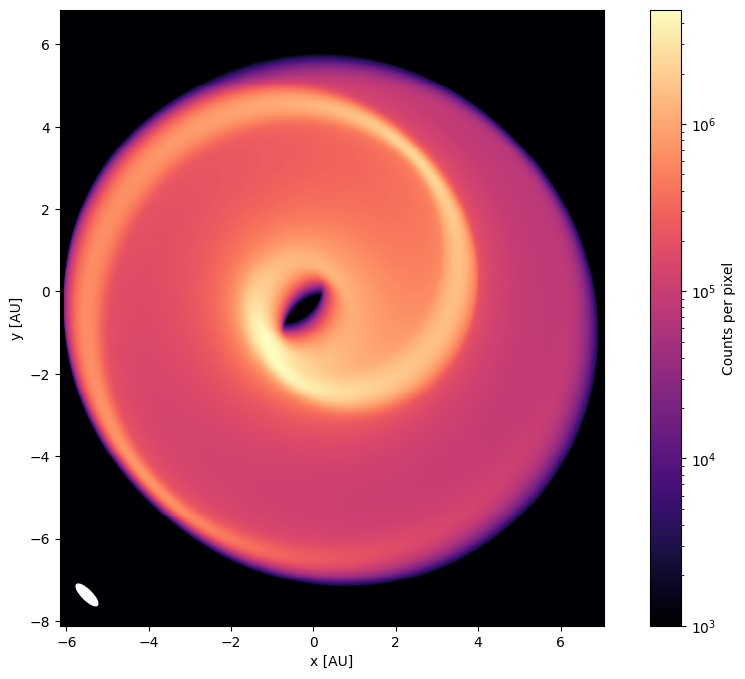

In [17]:
convolved = cartesian_histogram.convolve_gaussian(sigma_x=0.1, sigma_y=0.3, theta= 3.14/4)
ax = convolved.plot(cmap = "magma", log = True, floor_threshold=1e3, floor_value=1e3, 
                    show_psf=True, psf_scale=1, psf_loc=(0.05, 0.05), 
                    psf_facecolor="white", psf_edgecolor="white", psf_alpha=1.0)